# Tu primera red bayesiana: diagnosticar un incidente en producción
### Actividad guiada (independencia condicional y estructura causal)

En clase dijimos que la independencia **no vive en los datos, sino en el modelo** que uno impone, y vimos tres fenómenos/estructuras que rompen la intuición:

- **causa común**: dos efectos de una misma causa se ven correlacionados, y esa correlación **se disuelve** al condicionar en la causa (es la del niño y la edad)

- **colisionador**: dos causas independientes de un mismo efecto se vuelven dependientes **al condicionar en el efecto** (*explaining away*)

- y la cuenta que se dispara: especificar la conjunta de $n$ variables binarias "a mano" pide $2^n-1$ números, salvo que uno **declare independencias condicionales** y desplome esa cuenta.

Una red bayesiana es un lenguaje para **declarar** esas independencias con un grafo y llevar la contabilidad sin equivocarse. Hoy vamos a construir una desde cero, con las manos: definimos las tablas, escribimos la factorización, y programamos un motor de inferencia por **enumeración**. Con eso vamos a *ver* aparecer el *explaining away* en números, sin que nadie lo haya programado. Al final, el puente a la herramienta real (`pgmpy`), que hace lo mismo con un algoritmo más listo.

**El dominio (nuevo).** Un modelo de Machine Learning está en producción con su tablero de monitoreo. Dos cosas malas pueden estar pasando por debajo:

- $D$: hubo **drift de datos** (la distribución de entrada se movió), y
- $B$: el último **deploy metió un bug**.

Y observamos tres señales:

- $Q$: el monitoreo dispara una **alerta de calidad** (una métrica del modelo se degradó);
- $L$: el servicio muestra **latencia alta**;
- $P$: le llega un **page** (PagerDuty) a quien está de guardia.

**Cómo trabajar.** Ejecuten las celdas en orden. Hay algunos `TODO` de una línea y varios *Punto de reflexión* para escribir a mano. El motor pesado ya está puesto; lo suyo es interpretar y, sobre todo, **predecir antes de correr**: anoten su intuición y luego confróntenla con el número.

**Una nota de lenguaje** Vamos a dibujar flechas y a hablar de "causas". Cuidado: el grafo es una **decisión de modelado**, no un hecho leído en los datos. La red codifica un juego de independencias condicionales que *nosotros elegimos firmar*. Que la inferencia funcione bonito no prueba que la historia causal sea la verdadera; los mismos datos son compatibles con otras. Describir con un grafo no es explicar.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# Paleta del curso (la misma de las slides)
C_SLATE = "#283747"   # neutro
C_TEAL  = "#169685"   # a favor / sube
C_WARN  = "#b03a2e"   # alerta / baja
C_GOLD  = "#bc8e3a"   # acento

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 11})

## El grafo: qué depende de qué

Cuatro flechas, y ni una más. Cada una es una decisión sobre el mundo:

- $D \rightarrow Q$: el drift degrada la calidad del modelo.
- $B \rightarrow Q$: un bug también degrada la calidad. **$Q$ es un colisionador**: dos causas ($D$, $B$) apuntando al mismo efecto.
- $B \rightarrow L$: el mismo bug encima ralentiza el servicio. Entonces **$B$ es causa común** de $Q$ y de $L$.
- $Q \rightarrow P$: la alerta de calidad es la que dispara el page.

Fíjense en lo que el grafo **calla**: no hay flecha $D \rightarrow L$. Estamos firmando que el drift, por sí solo, no cambia la latencia. Y no hay flecha entre $D$ y $B$: los declaramos **independientes a priori**. Esa ausencia de flechas es toda la apuesta.

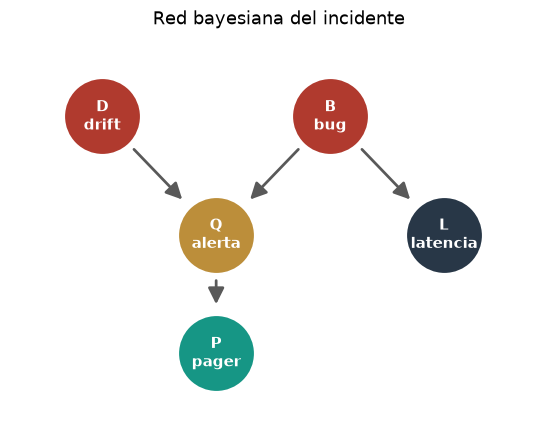

In [2]:
def dibuja_dag():
    pos = {"D": (0.0, 2.0), "B": (2.0, 2.0), "Q": (1.0, 1.0),
           "L": (3.0, 1.0), "P": (1.0, 0.0)}
    etiq = {"D": "D\ndrift", "B": "B\nbug", "Q": "Q\nalerta",
            "L": "L\nlatencia", "P": "P\npager"}
    col = {"D": C_WARN, "B": C_WARN, "Q": C_GOLD, "L": C_SLATE, "P": C_TEAL}
    edges = [("D", "Q"), ("B", "Q"), ("B", "L"), ("Q", "P")]
    fig, ax = plt.subplots(figsize=(5.2, 4.2))
    for a, b in edges:
        xa, ya = pos[a]; xb, yb = pos[b]
        ax.annotate("", xy=(xb, yb), xytext=(xa, ya),
                    arrowprops=dict(arrowstyle="-|>", color="0.35", lw=1.8,
                                    mutation_scale=22, shrinkA=30, shrinkB=32))
    for n, (x, y) in pos.items():
        ax.scatter([x], [y], s=2600, color=col[n], zorder=3, edgecolors="white", linewidths=2)
        ax.text(x, y, etiq[n], ha="center", va="center", color="white",
                fontsize=10, fontweight="bold", zorder=4)
    ax.set_xlim(-0.8, 3.9); ax.set_ylim(-0.7, 2.7)
    ax.axis("off"); ax.set_title("Red bayesiana del incidente", fontsize=12)
    plt.tight_layout(); plt.show()

dibuja_dag()

## Paso 1 las tablas de probabilidad condicional (CPT): el contrato de la red

Cada nodo trae **una tabla**: la probabilidad de la variable dada la de sus padres. Un nodo sin padres ($D$, $B$) trae solo su probabilidad a priori. Esto es el eco directo del dispositivo "¿qué estás firmando?" de la S2, ahora repartido nodo por nodo.

Lean los números como afirmaciones sobre el mundo, no como decoración:

- el drift es **poco frecuente** ($5\%$), un bug de deploy algo más ($10\%$);
- un bug degrada la calidad casi siempre ($80\%$); el drift, bastante ($70\%$); sin ninguno de los dos, la métrica se degrada rara vez ($2\%$, ruido del monitoreo);
- **solo el bug** ensucia la latencia ($85\%$ contra $3\%$ de base);
- el page es un sensor casi fiel de la alerta ($95\%$), con un $5\%$ de pages espurios.

In [3]:
# Nodos raiz: P(=1)
pD = {1: 0.05, 0: 0.95}     # drift de datos
pB = {1: 0.10, 0: 0.90}     # bug de deploy

# P(Q=1 | D, B)  -- Q es el colisionador
pQ = {(0, 0): 0.02,   # ni drift ni bug: casi nunca se degrada
      (1, 0): 0.70,   # solo drift
      (0, 1): 0.80,   # solo bug
      (1, 1): 0.95}   # ambos

pL = {1: 0.85, 0: 0.03}     # P(L=1 | B):  solo el bug sube la latencia
pP = {1: 0.95, 0: 0.05}     # P(P=1 | Q):  el pager sigue a la alerta

## Paso 2 la conjunta se factoriza (la regla de la cadena, con estructura)

La red afirma que la conjunta de las cinco variables se parte en un producto de tablas locales, cada una condicionada **solo a sus padres**:

$$P(D,B,Q,L,P) = P(D)\,P(B)\,P(Q\mid D,B)\,P(L\mid B)\,P(P\mid Q).$$

Cuenten los parámetros. La conjunta "a mano" pediría $2^5-1 = 31$ números. Esta factorización pide $1+1+4+2+2 = 10$. Con más variables la brecha se vuelve abismal: es exactamente el desplome "de mil a veinte" de las slides. **Cada flecha que *no* dibujaste es un parámetro que te ahorras, porque es una independencia que decidiste firmar.**

Completen el único término que falta en la factorización.

In [4]:
def conjunta(d, b, q, l, p):
    '''P(D=d, B=b, Q=q, L=l, P=p) segun la factorizacion de la red.'''
    P_D = pD[d]
    P_B = pB[b]
    P_Q = pQ[(d, b)] if q == 1 else 1 - pQ[(d, b)]
    P_L = pL[b] if l == 1 else 1 - pL[b]
    # TO-DO (1): completa el termino P(P=p | Q=q) usando pP, igual que las lineas de arriba.
    P_P = pP[q] if p == 1 else 1 - pP[q]
    return P_D * P_B * P_Q * P_L * P_P

# chequeo: la conjunta sobre las 32 combinaciones debe sumar 1
total = sum(conjunta(*c) for c in product([0, 1], repeat=5))
print(f"Suma de la conjunta sobre las 32 combinaciones = {total:.6f}  (debe ser 1.0)")

Suma de la conjunta sobre las 32 combinaciones = 1.000000  (debe ser 1.0)


## Paso 3 el motor de inferencia: enumeración

Cualquier pregunta del tipo $P(\text{objetivo}=v \mid \text{evidencia})$ se contesta por **fuerza bruta**: recorro las 32 combinaciones, me quedo con las compatibles con la evidencia, sumo sus probabilidades, y dentro de esas, la fracción donde el objetivo vale $v$. Es la definición de condicional de la S3, literal:

$$P(\text{obj}=v\mid \text{ev}) = \frac{\sum_{\text{mundos con ev y obj}=v} P(\text{mundo})}{\sum_{\text{mundos con ev}} P(\text{mundo})}.$$

Funciona perfecto aquí, y es **exponencial** en el número de variables: por eso las herramientas reales usan algo más astuto (eliminación de variables), que veremos al final. La idea, sin embargo, es esta.

In [5]:
def query(target, tval, evidence):
    '''P(target = tval | evidence), por enumeracion. evidence es un dict, p.ej. {'P':1}.'''
    num = den = 0.0
    for d, b, q, l, p in product([0, 1], repeat=5):
        mundo = dict(D=d, B=b, Q=q, L=l, P=p)
        if any(mundo[k] != v for k, v in evidence.items()):
            continue                      # descarta mundos que contradicen la evidencia
        pr = conjunta(d, b, q, l, p)
        den += pr
        if mundo[target] == tval:
            num += pr
    return num / den

# atajo para leer resultados en porcentaje
def pct(x):
    return f"{100*x:5.1f}%"


## Consulta 0 antes de cualquier evidencia: $D$ y $B$ son independientes

El colisionador $Q$ todavía está "cerrado" (no hemos observado nada aguas abajo). La red debería decir que saber del bug no cambia nada sobre el drift.

In [10]:
print("Priors:")
print(f"  P(D=1) = {pct(query('D',1,{}))}")
print(f"  P(B=1) = {pct(query('B',1,{}))}")
print("\nD y B, a priori:")
print(f"  P(D=1)       = {pct(query('D',1,{}))}")
print(f"  P(D=1 | B=1) = {pct(query('D',1,{'B':1}))}")
print(f"  P(D=1 | B=0) = {pct(query('D',1,{'B':0}))}")

Priors:
  P(D=1) =   5.0%
  P(B=1) =  10.0%

D y B, a priori:
  P(D=1)       =   5.0%
  P(D=1 | B=1) =   5.0%
  P(D=1 | B=0) =   5.0%


**Punto de reflexión 1.** Los tres números de abajo son idénticos. Escriban con sus palabras qué está afirmando la red al hacer eso, y por qué es consecuencia de que $D$ y $B$ no tengan flecha entre sí *ni un hijo observado en común todavía*.

Los tres números son idénticos porque la red declara que D y B no tienen ninguna flecha ni hijo que los una. Mientras el colisionador Q  no tiene ningún condicionamiento. Saber del bug no aporta información sobre el drift, por lo que son causas independientes de un mismo efecto y esa independencia se mantiene mientras no miremos el efecto.


## Consulta 1 suena el pager ($P=1$): ¿qué está pasando?

Quien está de guardia recibe el page. No sabe nada más. ¿Qué tan probable es cada culpa?

**Antes de correr, predigan:** ¿subirá más la sospecha de bug o de drift? ¿Alguna llegará a ser "casi seguro"?

In [11]:
# TO-DO (2): completa las dos consultas condicionando en el pager, P=1.
pB_dado_P = query('B', 1, {'P': 1})   # P(B=1 | P=1)
pD_dado_P = query('D', 1, {'P': 1})   # P(D=1 | P=1)

print(f"P(B=1 | P=1) = {pct(pB_dado_P)}   (prior era 10.0%)")
print(f"P(D=1 | P=1) = {pct(pD_dado_P)}   (prior era  5.0%)")

P(B=1 | P=1) =  46.7%   (prior era 10.0%)
P(D=1 | P=1) =  21.1%   (prior era  5.0%)


**Punto de reflexión 2.** El page dispara la sospecha de bug de $10\%$ a cerca de $47\%$, y la de drift de $5\%$ a cerca de $21\%$. Suben las dos, y el bug más (tenía mayor prior y pega más fuerte a la calidad). Pero fíjense: **ni siquiera con el pager sonando el bug llega a ser probable "más que no"**. Es el mismo fenómeno de la tasa base del test médico de la S3: una señal buena, sobre una causa poco frecuente, deja la probabilidad lejos de la certeza. ¿Por qué reaccionar como si fuera certeza ("otra vez el bug de siempre") es un error de tasa base?

El pager es una señal buena pero no perfecta y las causas son raras de entrada. Aunque el pager multiplica por casi cinco la sospecha de bug, como el bug era poco probable al inicio, el resultado queda lejos de la certeza. Creer que el pager confirma el bug es el error de tasa base, no es lo mismo entenderdelo como un camino de A a B o viceversa.

## Consulta 2 el momento *explaining away*

Segundos después, alguien confirma en el log que **el deploy sí traía un bug** ($B=1$). ¿Qué le pasa a tu sospecha de drift?

**Predigan el signo del cambio antes de correr.**

In [12]:
base   = query('D', 1, {'P': 1})
con_B  = query('D', 1, {'P': 1, 'B': 1})
sin_B  = query('D', 1, {'P': 1, 'B': 0})

print(f"P(D=1 | P=1)        = {pct(base)}")
print(f"P(D=1 | P=1, B=1)   = {pct(con_B)}   <- confirmado el bug: el drift se vuelve MENOS probable")
print(f"P(D=1 | P=1, B=0)   = {pct(sin_B)}   <- descartado el bug: el drift SUBE, ya es el mejor sospechoso")

P(D=1 | P=1)        =  21.1%
P(D=1 | P=1, B=1)   =   5.8%   <- confirmado el bug: el drift se vuelve MENOS probable
P(D=1 | P=1, B=0)   =  34.5%   <- descartado el bug: el drift SUBE, ya es el mejor sospechoso


**Punto de reflexión 3.** A priori, $D$ y $B$ eran independientes (Consulta 0). Pero **condicionados en una consecuencia común** (el page, aguas abajo de la alerta $Q$), se volvieron competidores: confirmar el bug *desinfla* al drift, descartarlo lo *infla*. Dos causas que no tenían ninguna relación ahora se pelean por explicar la misma evidencia.

> **Punto de rigor.** Nadie programó esa resta. No hay una regla "si hay bug, baja el drift" en ninguna celda. Es la propia estructura del colisionador la que la produce, vía la aritmética de la conjunta. La **dirección** del cambio la garantiza la forma del grafo; la **magnitud** depende de las CPTs que ustedes pusieron (qué tan raros son drift y bug, qué tan fielmente pega cada uno a la calidad). Cambien un prior y la magnitud se mueve; el signo, no.

Al principio drift y bug eran independientes. Pero cuando condicionamos en el pager, que está aguas abajo del colisionador, ese colisionador se abre y las dos causas se vuelven competidoras. Confirmar el bug explica el pager, entonces el drift ya no necesita explicarlo y su probabilidad baja. Descartar el bug deja al drift como único sospechoso y su probabilidad sube.

## Consulta 3 la evidencia viaja por el grafo (explaining away a distancia)

Ahora no confirmamos el bug directamente. Miramos **otra** señal: la latencia. Recuerden que solo el bug sube la latencia ($B \rightarrow L$), así que $L$ es un testigo indirecto de $B$, y $B$ compite con $D$ por explicar el page. La evidencia debería viajar: $L \Rightarrow B \Rightarrow$ (explaining away) $\Rightarrow D$.

In [13]:
print("Con el pager sonando (P=1), miramos la latencia:\n")
print(f"P(B=1 | P=1)        = {pct(query('B',1,{'P':1}))}")
print(f"P(B=1 | P=1, L=1)   = {pct(query('B',1,{'P':1,'L':1}))}   <- latencia alta casi confirma el bug")
print()
# TO-DO (3): completa las dos consultas sobre el drift segun lo que diga la latencia.
pD_L1 = query('D', 1, {'P':1, 'L':1})   # P(D=1 | P=1, L=1)
pD_L0 = query('D', 1, {'P':1, 'L':0})   # P(D=1 | P=1, L=0)
print(f"P(D=1 | P=1, L=1)   = {pct(pD_L1)}   <- el bug ya explica todo: el drift se desinfla")
print(f"P(D=1 | P=1, L=0)   = {pct(pD_L0)}   <- latencia normal: el bug pierde fuerza, el drift sube")

Con el pager sonando (P=1), miramos la latencia:

P(B=1 | P=1)        =  46.7%
P(B=1 | P=1, L=1)   =  96.1%   <- latencia alta casi confirma el bug

P(D=1 | P=1, L=1)   =   6.9%   <- el bug ya explica todo: el drift se desinfla
P(D=1 | P=1, L=0)   =  31.1%   <- latencia normal: el bug pierde fuerza, el drift sube


**Punto de reflexión 4.** Esto es lo bonito de una red: la evidencia sobre la latencia, que no toca a $D$ por ninguna flecha directa, **cambia** la probabilidad del drift. Viajó $L \to B \to Q \to$ (colisionador) $\to D$. Y noten el contraste brutal: con el pager sonando, ver **latencia alta** deja el drift en $\approx 7\%$, mientras que ver **latencia normal** lo deja en $\approx 31\%$. La misma alerta, dos diagnósticos casi opuestos, según una señal lateral. ¿Qué les dice esto sobre diagnosticar un incidente mirando una sola métrica?

La latencia no tiene flecha directa hacia el drift, pero la evidencia igual llega. El camino que se sigue va de latencia informa sobre el bug, a el bug compite con el drift por explicar la alerta, y esa competencia mueve la probabilidad del drift. Ver latencia alta sube la sospecha de bug y desinfla el drift. Ver latencia normal hace lo contrario.

## Consulta 4 la causa común: una dependencia que se disuelve

$B$ es causa común de $Q$ (alerta) y de $L$ (latencia). Entonces alerta y latencia deberían verse **correlacionadas** en la operación diaria... hasta que uno sepa si hubo bug o no. Ahí, la correlación se disuelve: es el caso "causa común" de la S3, en vivo.

In [14]:
print(f"P(L=1)              = {pct(query('L',1,{}))}")
print(f"P(L=1 | Q=1)        = {pct(query('L',1,{'Q':1}))}   <- saber que hubo alerta sube la latencia esperada")
print("   => alerta y latencia estan asociadas marginalmente\n")
print(f"P(L=1 | Q=1, B=1)   = {pct(query('L',1,{'Q':1,'B':1}))}")
print(f"P(L=1 | Q=0, B=1)   = {pct(query('L',1,{'Q':0,'B':1}))}   <- IGUALES dado B")
print("   => dado el bug, la alerta ya no aporta nada sobre la latencia:  L ⊥ Q | B")

P(L=1)              =  11.2%
P(L=1 | Q=1)        =  54.2%   <- saber que hubo alerta sube la latencia esperada
   => alerta y latencia estan asociadas marginalmente

P(L=1 | Q=1, B=1)   =  85.0%
P(L=1 | Q=0, B=1)   =  85.0%   <- IGUALES dado B
   => dado el bug, la alerta ya no aporta nada sobre la latencia:  L ⊥ Q | B


**Punto de reflexión 5.** Marginalmente, alerta y latencia van de la mano (ambas las levanta el bug). Pero una vez que sabes si hubo bug, la alerta deja de decirte nada nuevo sobre la latencia. Es la estructura que asume Naive Bayes (S3): los "síntomas" son condicionalmente independientes dada la "causa". Contrasten esto, en una frase, con el colisionador de la Consulta 2: ahí condicionar **creó** dependencia; aquí condicionar la **destruye**. ¿Qué cambió, en términos de la forma del grafo (flechas que entran contra flechas que salen del nodo condicionado)?

En el colisionador, condicionar en el efecto crea dependencia entre las dos causas, lo que nos hace pensar que las flechas entran al nodo que condicionamos. En la causa común, condicionar en el padre destruye la dependencia entre los efectos, dando a entender que las flechas salen del nodo que condicionamos.


## Una figura para no olvidarlo: la probabilidad de drift, según lo que sabes

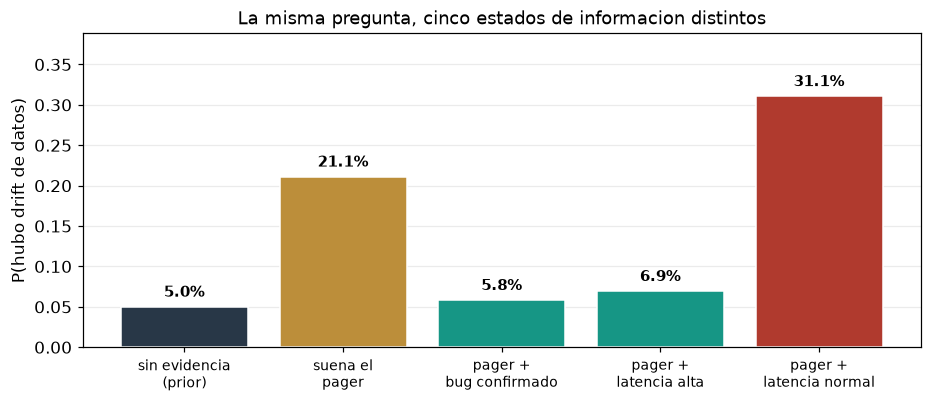

In [15]:
escenarios = [
    ("sin evidencia\n(prior)",        query('D',1,{})),
    ("suena el\npager",               query('D',1,{'P':1})),
    ("pager +\nbug confirmado",       query('D',1,{'P':1,'B':1})),
    ("pager +\nlatencia alta",        query('D',1,{'P':1,'L':1})),
    ("pager +\nlatencia normal",      query('D',1,{'P':1,'L':0})),
]
labels = [e[0] for e in escenarios]
vals   = [e[1] for e in escenarios]
cols   = [C_SLATE, C_GOLD, C_TEAL, C_TEAL, C_WARN]

fig, ax = plt.subplots(figsize=(8.6, 3.8))
bars = ax.bar(range(len(vals)), vals, color=cols, edgecolor="white")
for i, v in enumerate(vals):
    ax.text(i, v + 0.008, f"{100*v:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("P(hubo drift de datos)")
ax.set_ylim(0, max(vals)*1.25); ax.set_axisbelow(True); ax.grid(axis="x", alpha=0)
ax.set_title("La misma pregunta, cinco estados de informacion distintos", fontsize=12)
plt.tight_layout(); plt.show()

**Punto de reflexión 6.** Ninguna barra cambió porque cambiaran los datos del mundo: cambiaron porque cambió **lo que sabemos**. La probabilidad no es una propiedad de $D$ esperando ser medida, sino que más bien es relativa a un estado de información, exactamente como discutimos en la S1 con el temblor. La red bayesiana es la máquina que actualiza ese estado de forma coherente.

Las barras cambian porque cambió lo que sabemos, no el mundo. El drift sigue siendo el mismo evento con la misma frecuencia real. Lo que cambia es nuestra creencia sobre él, actualizada de forma coherente por la red. La red bayesiana es la máquina que actualiza ese estado sin contradecirse.

## El puente a la herramienta real: `pgmpy`

Programar la enumeración a mano fue el punto: vieron la factorización y la aritmética del *explaining away* sin caja negra. Pero enumerar $2^n$ mundos no escala. En la práctica se usa una librería que hace **eliminación de variables** (o *belief propagation*): mismo resultado exacto, sin recorrer todos los mundos.

La celda siguiente arma **la misma red** en `pgmpy` y reproduce dos consultas clave. Es su autochequeo: los números deben coincidir con los de arriba hasta el redondeo. Si en su entorno no tienen `pgmpy`, instálenlo con `pip install pgmpy` (viene con el stack del curso); la celda avisa amablemente si falta y no rompe el notebook.

> **Nota de versión.** `pgmpy` renombró `BayesianNetwork` a `DiscreteBayesianNetwork` en versiones recientes; el `import` de abajo tolera ambas. El orden de las columnas en un `TabularCPD` con varios padres importa: la última variable de `evidence` es la que cambia más rápido.

In [17]:
try:
    try:
        from pgmpy.models import DiscreteBayesianNetwork as BN
    except ImportError:
        from pgmpy.models import BayesianNetwork as BN
    from pgmpy.factors.discrete import TabularCPD
    from pgmpy.inference import VariableElimination

    modelo = BN([("D", "Q"), ("B", "Q"), ("B", "L"), ("Q", "P")])

    cpd_D = TabularCPD("D", 2, [[0.95], [0.05]])
    cpd_B = TabularCPD("B", 2, [[0.90], [0.10]])
    # columnas de Q en orden (D,B) = (0,0),(0,1),(1,0),(1,1); fila 0 = Q=0, fila 1 = Q=1
    cpd_Q = TabularCPD("Q", 2,
                       [[0.98, 0.20, 0.30, 0.05],
                        [0.02, 0.80, 0.70, 0.95]],
                       evidence=["D", "B"], evidence_card=[2, 2])
    cpd_L = TabularCPD("L", 2, [[0.97, 0.15], [0.03, 0.85]],
                       evidence=["B"], evidence_card=[2])
    cpd_P = TabularCPD("P", 2, [[0.95, 0.05], [0.05, 0.95]],
                       evidence=["Q"], evidence_card=[2])

    modelo.add_cpds(cpd_D, cpd_B, cpd_Q, cpd_L, cpd_P)
    assert modelo.check_model()
    infer = VariableElimination(modelo)

    p_da = infer.query(["D"], evidence={"P": 1}, show_progress=False).values[1]
    p_db = infer.query(["D"], evidence={"P": 1, "B": 1}, show_progress=False).values[1]

    print("pgmpy  vs  enumeracion a mano")
    print(f"  P(D=1 | P=1)      : pgmpy {p_da:.4f}   a mano {query('D',1,{'P':1}):.4f}")
    print(f"  P(D=1 | P=1, B=1) : pgmpy {p_db:.4f}   a mano {query('D',1,{'P':1,'B':1}):.4f}")
    print("\nCoinciden: la enumeracion y la eliminacion de variables dan el MISMO exacto.")
except ImportError:
    print("pgmpy no esta instalado en este entorno.")
    print("Instalalo con:  pip install pgmpy")
    print("La parte 'desde cero' de arriba ya te dio todos los resultados; esto es solo el puente.")

pgmpy  vs  enumeracion a mano
  P(D=1 | P=1)      : pgmpy 0.2111   a mano 0.2111
  P(D=1 | P=1, B=1) : pgmpy 0.0583   a mano 0.0583

Coinciden: la enumeracion y la eliminacion de variables dan el MISMO exacto.


## Reto (opcional, pero se lo recomiendo)

Extiendan la red y vuelvan a preguntar. Dos ideas:

1. **Un testigo más para el bug.** Agreguen un nodo $R$ = "un *rollback* del deploy arregló la métrica", hijo de $B$ (solo el bug se arregla con rollback). Con el pager sonando, ¿cómo cambia $P(D=1)$ al enterarse de que el rollback **sí** funcionó? Predigan el signo y verifíquenlo.
2. **Muevan un prior.** Suban $P(B=1)$ de $0.10$ a $0.40$ (un equipo que despliega mucho y con prisa). ¿El *explaining away* de la Consulta 2 se vuelve más fuerte o más débil? ¿Por qué?

Para el punto 1 solo tienen que agregar `pR = {1: ..., 0: ...}`, meter $R$ en `conjunta` y en `query` (ahora son 6 variables, `product([0,1], repeat=6)`), y correr. Verán que el motor no cambia: solo crece.

## Cierre

Construyeron una red bayesiana desde cero y la vieron razonar. Todo lo que pasó ya estaba en la S3, ahora en código:

| Fenómeno | Estructura en el grafo | Lo que vieron |
|---|---|---|
| Independencia a priori | sin flecha $D\!-\!B$, colisionador cerrado | $P(D\mid B)=P(D)$ (Consulta 0) |
| *Explaining away* | condicionar en un **efecto común** | confirmar el bug desinfla el drift (Consulta 2) |
| Evidencia que viaja | camino $L\!\to\!B\!\to\!Q\!\to\!D$ | la latencia mueve al drift sin tocarlo (Consulta 3) |
| Causa común | condicionar en el **padre** compartido | $L \perp\!\!\!\perp Q \mid B$ (Consulta 4) |
| Economía del modelo | flechas ausentes = independencias | $10$ parámetros en vez de $31$ |

La moraleja, la misma de la S3 subida a máquina: **elegir el grafo es elegir qué independencias firmar**, y con ellas, qué historia estás dispuesto a contar. La red hizo el *explaining away* sin que nadie lo programara, porque la estructura ya lo contenía. Y, fieles a la postura de clase: que la inferencia salga elegante no vuelve verdadera la historia causal; el mismo tablero de datos es compatible con otras estructuras. Describir con un grafo, otra vez, no es explicar.

**Preguntas de cierre** (para escribir a mano):

1. En una frase: ¿por qué condicionar en un colisionador *crea* dependencia, mientras condicionar en una causa común la *destruye*?
2. La Consulta 3 movió $P(D)$ mirando la latencia, que no tiene flecha a $D$. Expliquen la ruta por la que viajó esa información.
3. ¿Por qué la cuenta de parámetros ($31$ contra $10$ aquí, "mil contra veinte" en las slides) no es un detalle de eficiencia, sino la razón de fondo por la que las redes bayesianas existen?

**Para leer más.** Sucar, *Probabilistic Graphical Models: Principles and Applications* (Springer). Pearl, *Causality*, para cuando quieran cruzar de "describir independencias" a "hablar de intervenciones" (eso es la S24). Koller y Friedman, *Probabilistic Graphical Models*, como referencia enciclopédica.

1. En un colisionador, dos causas independientes compiten por explicar el efecto observado. Si una está presente, la otra se vuelve menos necesaria; eso las vuelve dependientes. En una causa común, la dependencia entre los efectos viene solo de la causa compartida; al fijar esa causa, los efectos quedan desconectados y la dependencia desaparece.

2. La latencia informa sobre el bug, el bug compite con el drift por explicar la alerta, y esa competencia cambia la probabilidad del drift. La información no viaja por una flecha directa (no existe), sino por un camino que pasa por el colisionador.

3. Porque sin independencias condicionales, la conjunta de muchas variables binarias pide un número de parámetros que crece exponencialmente y se vuelve imposible de especificar. La factorización basada en el grafo reduce la cuenta a la suma de tablas locales, que crece de forma manejable.La estructura del grafo es lo que hace viable el modelado probabilístico.